# IdiomX — Task 2: Context-to-Idiom Prediction

- **Author:** Ayman Ali Sharara  
- **Project:** IdiomX — Neural Understanding of English Idioms  
- **GitHub dataset:** https://github.com/aymanshar/idiomx-dataset  
- **GitHub deep learning repository:** https://github.com/aymanshar/IdiomX  
- **Year:** 2026  

---

## 🎯 Objective

Predict the **canonical idiom** from a given contextual sentence.

---

## 📥 Input

A contextual sentence expressing an idiomatic meaning.

---

## 📤 Output

The corresponding idiom in its canonical form.

---

## 🧠 Task Formulation

This task is formulated as a **closed-set retrieval problem**:

- A fixed **idiom bank** is constructed.
- Each query must retrieve the correct idiom from this candidate set.
- Evaluation is performed using **Top-k accuracy and MRR**.

---

## 🧩 Modeling Pipeline

The task is solved using a multi-stage retrieval architecture:

1. **Sparse Retrieval (TF-IDF)**  
   Captures lexical overlap.

2. **Dense Retrieval (MiniLM / E5)**  
   Captures semantic similarity.

3. **Hybrid Retrieval**  
   Combines sparse and dense signals.

4. **Cross-Encoder Reranking**  
   Refines candidate ranking using deep pairwise scoring.

---

## 🧪 Evaluation Metrics

- Top-1 Accuracy  
- Top-3 Accuracy  
- Top-5 Accuracy  
- Mean Reciprocal Rank (MRR)

---

## 🔒 Reproducibility

This notebook ensures reproducibility by:

- fixing random seeds  
- using deterministic data splits  
- building the benchmark from raw data  
- avoiding data leakage through query-level splitting  

---

## 📌 Note

This notebook constructs a **clean Task 2 benchmark from scratch**, including:
- dataset preparation  
- leakage-free splitting  
- idiom bank construction  
- retrieval and reranking evaluation  

---

## 📜 License

This work is released under the MIT License.

---

## 📖 Citation

If you use this dataset or benchmark, please cite the IdiomX research paper.

## Task 2: Context-to-Idiom Prediction

This task focuses on predicting the canonical idiom from a contextual sentence. Given a sentence expressing an idiomatic meaning, the objective is to identify the corresponding idiom in its canonical form.

In this notebook, the dataset is loaded directly from the online IdiomX release and a clean Task 2 benchmark is constructed from scratch. This allows full control over filtering, split strategy, leakage checks, and candidate bank design.

## 1. Environment Setup and Reproducibility

This notebook evaluates idiom detection as a binary classification task, where the goal is to predict whether a sentence uses an idiom figuratively or literally.

To ensure reproducibility, we begin by:
- importing required libraries
- fixing random seeds
- defining project and artifact paths
- preparing directories for outputs, figures, tables, and saved models

This notebook is designed to be reproducible and publication-oriented. Data loading and splitting will be performed explicitly in later sections.

In [75]:
# Reproducibility

import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [1]:
# [1.1] Environment setup and reproducibility

from pathlib import Path
import os
import random
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Display options for cleaner inspection in notebook
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.precision", 4)

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("Random seed:", SEED)

# -----------------------------
# Project paths
# -----------------------------
# Assumes notebook is inside the project repository
PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "task2_context_to_idiom"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"
MODELS_DIR = PROJECT_ROOT / "deep_learning" / "models" / "task2_context_to_idiom"

# Create output directories if missing
for folder in [OUTPUTS_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("OUTPUTS_DIR  :", OUTPUTS_DIR)
print("FIGURES_DIR  :", FIGURES_DIR)
print("TABLES_DIR   :", TABLES_DIR)
print("MODELS_DIR   :", MODELS_DIR)

Random seed: 42
PROJECT_ROOT : C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX
OUTPUTS_DIR  : C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task2_context_to_idiom
FIGURES_DIR  : C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task2_context_to_idiom\figures
TABLES_DIR   : C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task2_context_to_idiom\tables
MODELS_DIR   : C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task2_context_to_idiom


## 2. Load Dataset

We load the IdiomX dataset directly from Hugging Face to ensure reproducibility and avoid dependence on locally pre-split files.

At this stage, we:
- load the full dataset
- inspect its schema
- verify that the fields required for context-to-idiom prediction are present
- prepare a clean working dataframe for filtering and split construction

In [2]:
# [2.1] Load IdiomX from Hugging Face

from datasets import load_dataset

HF_DATASET_NAME = "aymansharara/idiomx"

dataset = load_dataset(HF_DATASET_NAME)

print(dataset)
print("\nAvailable splits:", list(dataset.keys()))

README.md: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


train.parquet:   0%|          | 0.00/31.2M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['idiom', 'meaning_en', 'example', 'source', 'source_type', 'pos', 'tags', 'idiom_confidence', 'source_url', 'idiom_canonical', 'idiom_canonical_meaning', 'idiom_canonical_meaning_arabic', 'is_idiom', 'ambiguity_flag', 'idiom_compositionality_level', 'idiom_register', 'idiom_domain', 'learner_difficulty', 'idiom_surface', 'idiom_in_example', 'idiom_in_example_arabic', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic', 'is_example_idiom', 'example_usage_label', 'is_generated_example', 'enrichment_model', 'enrichment_version', 'validation_status', 'example_length', 'idiom_present', 'contains_profanity', 'semantic_consistency', 'canonical_semantic_score'],
        num_rows: 123336
    })
})

Available splits: ['train']


In [4]:
# [2.2] Convert to pandas and inspect structure

# Prefer 'train' split if dataset is published as a single main split
df = dataset["train"].to_pandas().copy()

print("Full dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head(3))

# -----------------------------
# Save local cached copy (for reproducibility)
# -----------------------------
CACHE_PATH = DATA_DIR / "idiomx_full_dataset.parquet"
df.to_parquet(CACHE_PATH, index=False)

print("\nSaved local copy to:", CACHE_PATH)

Full dataset shape: (123336, 34)

Columns:
['idiom', 'meaning_en', 'example', 'source', 'source_type', 'pos', 'tags', 'idiom_confidence', 'source_url', 'idiom_canonical', 'idiom_canonical_meaning', 'idiom_canonical_meaning_arabic', 'is_idiom', 'ambiguity_flag', 'idiom_compositionality_level', 'idiom_register', 'idiom_domain', 'learner_difficulty', 'idiom_surface', 'idiom_in_example', 'idiom_in_example_arabic', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic', 'is_example_idiom', 'example_usage_label', 'is_generated_example', 'enrichment_model', 'enrichment_version', 'validation_status', 'example_length', 'idiom_present', 'contains_profanity', 'semantic_consistency', 'canonical_semantic_score']


,idiom,meaning_en,example,source,source_type,pos,tags,idiom_confidence,source_url,idiom_canonical,idiom_canonical_meaning,idiom_canonical_meaning_arabic,is_idiom,ambiguity_flag,idiom_compositionality_level,idiom_register,idiom_domain,learner_difficulty,idiom_surface,idiom_in_example,idiom_in_example_arabic,idiom_in_example_meaning_en,idiom_in_example_meaning_arabic,is_example_idiom,example_usage_label,is_generated_example,enrichment_model,enrichment_version,validation_status,example_length,idiom_present,contains_profanity,semantic_consistency,canonical_semantic_score
0,$100 hamburger,Used other than figuratively or idiomatically: see hamburger.,Daniel Boulud has a restaurant that serves a truffle and Kobe steak hamburger for $100 […] It's to make everything e...,kaikki_wiktionary,dictionary,noun,None,high,NaN,$100 hamburger,"In aviation and pilot culture, a ""$100 hamburger"" refers to a flight solely undertaken to justify the expense of fly...","في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول ...",True,ambiguous,semi_opaque,neutral,regional,medium,$100 hamburger,"Last weekend, Mark took a $100 hamburger trip just to enjoy flying and have lunch at a local diner.","في نهاية الأسبوع الماضي، قام مارك برحلة ""همبرغر بمئة دولار"" فقط للاستمتاع بالطيران وتناول الغداء في مطعم محلي.",The expression figuratively means that Mark flew purely for pleasure and to justify flying expense by having a simpl...,يعني التعبير مجازياً أن مارك طار فقط للمتعة ولتبرير تكلفة الطيران بتناول وجبة بسيطة في مطار آخر.,True,idiomatic,1,gpt-4.1-mini-2025-04-14,v2_4idiomatic_4literal,valid,19.0,True,False,0.5932,0.7621
1,$100 hamburger,Used other than figuratively or idiomatically: see hamburger.,Daniel Boulud has a restaurant that serves a truffle and Kobe steak hamburger for $100 […] It's to make everything e...,kaikki_wiktionary,dictionary,noun,None,high,NaN,$100 hamburger,"In aviation and pilot culture, a ""$100 hamburger"" refers to a flight solely undertaken to justify the expense of fly...","في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول ...",True,ambiguous,semi_opaque,neutral,regional,medium,$100 hamburger,Pilots often joke about taking a $100 hamburger when planning casual weekend flights.,"غالبًا ما يمزح الطيارون بشأن القيام برحلة ""همبرغر بمئة دولار"" عند التخطيط لرحلات نهاية الأسبوع العفوية.",Used figuratively to describe a casual flight taken mainly to enjoy flying rather than out of necessity.,تُستخدم مجازياً لوصف رحلة عادية تُقام أساسًا للاستمتاع بالطيران وليس من باب الضرورة.,True,idiomatic,1,gpt-4.1-mini-2025-04-14,v2_4idiomatic_4literal,valid,13.0,True,False,0.3871,0.8336
2,$100 hamburger,Used other than figuratively or idiomatically: see hamburger.,Daniel Boulud has a restaurant that serves a truffle and Kobe steak hamburger for $100 […] It's to make everything e...,kaikki_wiktionary,dictionary,noun,None,high,NaN,$100 hamburger,"In aviation and pilot culture, a ""$100 hamburger"" refers to a flight solely undertaken to justify the expense of fly...","في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول ...",True,ambiguous,semi_opaque,neutral,regional,medium,$100 hamburger,Her $100 hamburger flight was an excuse for a mini-vacation with friends.,كانت رحلة الهمبرغر بمئة دولار مبررًا لعطلة قصيرة مع الأصدقاء.,"Figuratively, the flight served as a recreational trip, with the meal as a justification.",مجازياً، كانت الرحلة بمثابة رحلة ترفيهية مع استخدام الوجبة كتبرير.,True,idiomatic,1,gpt-4.1-mini-2025-04-14,v2_4idiomatic_4literal,valid,12.0,True,False,0.5932,0.6841



Saved local copy to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\data\idiomx_full_dataset.parquet


In [12]:
# [2.3] Check required columns for Task 1

required_cols = [
    "idiom_in_example",
    "is_example_idiom",
    "idiom_canonical"
]

missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns for Task 1: {missing_cols}")

print("All required Task 1 columns are present.")

All required Task 1 columns are present.


## 3. Build the Task 2 Working Dataset

Task 2 is defined as predicting the canonical idiom from an idiomatic context.  
At this stage, we keep only rows where the example is labeled as idiomatic, because literal examples do not represent the intended target mapping for this task.

We then define:
- **query_text**: the contextual sentence used as model input
- **target_idiom**: the canonical idiom used as the prediction target

In [5]:
# [3.1] Keep only idiomatic examples and define Task 2 core fields

df_task2 = df.loc[df["is_example_idiom"] == True].copy()

df_task2["query_text"] = df_task2["example"].astype(str).str.strip()
df_task2["target_idiom"] = df_task2["idiom_canonical"].astype(str).str.strip()

print("Task 2 subset shape:", df_task2.shape)
print("Unique target idioms:", df_task2["target_idiom"].nunique())

display(
    df_task2[
        ["idiom", "idiom_canonical", "example", "query_text", "target_idiom", "is_example_idiom"]
    ].head(5)
)

Task 2 subset shape: (61720, 36)
Unique target idioms: 14971


,idiom,idiom_canonical,example,query_text,target_idiom,is_example_idiom
0,$100 hamburger,$100 hamburger,Daniel Boulud has a restaurant that serves a truffle and Kobe steak hamburger for $100 […] It's to make everything e...,Daniel Boulud has a restaurant that serves a truffle and Kobe steak hamburger for $100 […] It's to make everything e...,$100 hamburger,True
1,$100 hamburger,$100 hamburger,Daniel Boulud has a restaurant that serves a truffle and Kobe steak hamburger for $100 […] It's to make everything e...,Daniel Boulud has a restaurant that serves a truffle and Kobe steak hamburger for $100 […] It's to make everything e...,$100 hamburger,True
2,$100 hamburger,$100 hamburger,Daniel Boulud has a restaurant that serves a truffle and Kobe steak hamburger for $100 […] It's to make everything e...,Daniel Boulud has a restaurant that serves a truffle and Kobe steak hamburger for $100 […] It's to make everything e...,$100 hamburger,True
3,$100 hamburger,$100 hamburger,Daniel Boulud has a restaurant that serves a truffle and Kobe steak hamburger for $100 […] It's to make everything e...,Daniel Boulud has a restaurant that serves a truffle and Kobe steak hamburger for $100 […] It's to make everything e...,$100 hamburger,True
8,& ux.,et ux.,None,None,et ux.,True


---

## 4. Validate the Task 2 Core Data

Before constructing train, validation, and test splits, we verify that the Task 2 subset is clean.

At this stage, we check:
- missing values in the main input and target fields
- empty strings after cleaning
- duplicate query–target pairs
- number of idiomatic examples available per target idiom

These checks are important because the split strategy for this task depends on how many idiomatic contexts exist for each canonical idiom.

In [6]:
# [4.1] Basic validation of Task 2 input/target fields

print("Missing values:")
print(df_task2[["query_text", "target_idiom"]].isna().sum())

empty_query = (df_task2["query_text"].str.len() == 0).sum()
empty_target = (df_task2["target_idiom"].str.len() == 0).sum()

print("\nEmpty strings:")
print("Empty query_text   :", empty_query)
print("Empty target_idiom :", empty_target)

dup_pairs = df_task2.duplicated(subset=["query_text", "target_idiom"]).sum()
print("\nDuplicate query-target pairs:", dup_pairs)

idiom_counts = (
    df_task2.groupby("target_idiom")
    .size()
    .reset_index(name="idiomatic_example_count")
    .sort_values("idiomatic_example_count", ascending=False)
)

print("\nIdiomatic example count distribution:")
print(idiom_counts["idiomatic_example_count"].value_counts().sort_index())

display(idiom_counts.head(10))

Missing values:
query_text      0
target_idiom    0
dtype: int64

Empty strings:
Empty query_text   : 0
Empty target_idiom : 0

Duplicate query-target pairs: 46448

Idiomatic example count distribution:
idiomatic_example_count
1         8
2         9
3       137
4     14273
5       150
6        23
7        10
8       316
9         4
10        1
12       26
14        1
16        7
19        2
20        1
24        1
45        1
94        1
Name: count, dtype: int64


,target_idiom,idiomatic_example_count
552,None,94
3482,dance with the one that brought you,45
57,Bob's your uncle,24
14761,worship the porcelain god,20
8269,may the Force be with you,19
14890,you kiss your mother with that mouth,19
6762,in layman's terms,16
10086,poverty is a state of mind,16
869,add fuel to the fire,16
13440,time heals all wounds,16


## 5. Data Cleaning and Preparation for Splitting

Before applying the split strategy, we perform minimal cleaning:

- remove invalid targets (e.g., missing canonical idioms)
- normalize text fields
- ensure consistent string formatting

This step ensures that the split logic operates on clean and reliable data.

In [7]:
# [5.1] Remove invalid targets and normalize text

# Remove rows where canonical idiom is missing or invalid
df_task2 = df_task2[df_task2["target_idiom"].notna()].copy()

# Remove "None" string if exists
df_task2 = df_task2[df_task2["target_idiom"].str.lower() != "none"]

# Normalize text (important for matching later)
df_task2["query_text"] = df_task2["query_text"].str.strip()
df_task2["target_idiom"] = df_task2["target_idiom"].str.strip()

print("After cleaning shape:", df_task2.shape)
print("Unique idioms:", df_task2["target_idiom"].nunique())

After cleaning shape: (61626, 36)
Unique idioms: 14970


## 6. Group-Based Split Strategy (Leakage-Safe)

To construct a reliable benchmark, we apply a group-based split at the idiom level.

For each canonical idiom:
- if ≥ 4 idiomatic examples:
  - 2 → train
  - 1 → validation
  - 1 → test
- if > 4:
  - remaining examples → train
- if < 4:
  - all examples → train only

This ensures:
- no leakage across splits
- consistent evaluation per idiom
- sufficient training signal

The split is performed with fixed random seed for reproducibility.

In [8]:
# [6.1] Leakage-safe group-based split

from sklearn.model_selection import train_test_split

train_parts = []
val_parts = []
test_parts = []

for idiom, group in df_task2.groupby("target_idiom"):

    group = group.sample(frac=1, random_state=SEED)  # shuffle

    n = len(group)

    if n >= 4:
        train_g = group.iloc[:2]
        val_g = group.iloc[2:3]
        test_g = group.iloc[3:4]

        # extra samples → train
        if n > 4:
            extra = group.iloc[4:]
            train_g = pd.concat([train_g, extra], axis=0)

        train_parts.append(train_g)
        val_parts.append(val_g)
        test_parts.append(test_g)

    else:
        # too few samples → train only
        train_parts.append(group)

# Combine splits
train_df = pd.concat(train_parts).reset_index(drop=True)
val_df = pd.concat(val_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)

print("\nUnique idioms per split:")
print("Train:", train_df["target_idiom"].nunique())
print("Val  :", val_df["target_idiom"].nunique())
print("Test :", test_df["target_idiom"].nunique())

Train shape: (31994, 36)
Val shape  : (14816, 36)
Test shape : (14816, 36)

Unique idioms per split:
Train: 14970
Val  : 14816
Test : 14816


## 7. Split Sanity Checks

After constructing the train, validation, and test splits, we verify that there is no exact sentence leakage across partitions.

At this stage, we check:
- overlap of `query_text` between train and validation
- overlap of `query_text` between train and test
- overlap of `query_text` between validation and test

These checks help confirm that evaluation contexts are not duplicated across splits.

In [9]:
# [7.1] Exact query overlap across splits

train_queries = set(train_df["query_text"])
val_queries = set(val_df["query_text"])
test_queries = set(test_df["query_text"])

train_val_overlap = len(train_queries & val_queries)
train_test_overlap = len(train_queries & test_queries)
val_test_overlap = len(val_queries & test_queries)

print("Exact query overlap counts:")
print("Train ∩ Val :", train_val_overlap)
print("Train ∩ Test:", train_test_overlap)
print("Val ∩ Test  :", val_test_overlap)

Exact query overlap counts:
Train ∩ Val : 9414
Train ∩ Test: 9434
Val ∩ Test  : 9222


## 8. Remove Cross-Split Query Leakage

We remove exact duplicate query_text overlaps across splits.

To preserve training signal:
- training set is kept unchanged
- validation and test sets are filtered to remove any queries already seen in earlier splits

This ensures that evaluation is performed on unseen contexts.

In [10]:
# [8.1] Remove leakage from validation and test

# Remove overlap with train
val_df = val_df[~val_df["query_text"].isin(train_df["query_text"])].copy()
test_df = test_df[~test_df["query_text"].isin(train_df["query_text"])].copy()

# Remove overlap between val and test
test_df = test_df[~test_df["query_text"].isin(val_df["query_text"])].copy()

print("After leakage removal:")
print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)

After leakage removal:
Train shape: (31994, 36)
Val shape  : (0, 36)
Test shape : (0, 36)


In [11]:
# [8.2] Re-check overlap

train_queries = set(train_df["query_text"])
val_queries = set(val_df["query_text"])
test_queries = set(test_df["query_text"])

print("Train ∩ Val :", len(train_queries & val_queries))
print("Train ∩ Test:", len(train_queries & test_queries))
print("Val ∩ Test  :", len(val_queries & test_queries))

Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0


---

## 6. Diagnostic Check for Split Strategy

Before revising the split strategy, we check whether identical query sentences are reused across different idiom labels.

This helps determine whether grouping by `idiom` is sufficient, or whether additional query-level deduplication is still required.

In [17]:
# [6.1] Check whether the same query_text appears with multiple idiom labels

query_idiom_stats = (
    df_task2.groupby("query_text")["idiom"]
    .nunique()
    .reset_index(name="n_unique_idioms")
)

print(query_idiom_stats["n_unique_idioms"].value_counts().sort_index())

display(query_idiom_stats.sort_values("n_unique_idioms", ascending=False).head(10))

n_unique_idioms
1       9670
2         38
5631       1
Name: count, dtype: int64


,query_text,n_unique_idioms
5354,None,5631
1477,"Brüno was a case of diminishing returns, intermittently amusing but not nearly as bracing or funny as Borat—it didn’...",2
389,"""Whoever the hell is running the place now has made a terrible mess of it,"" he said... ""Not in the sense that it loo...",2
5009,"Mrs. Bowls cautioned her lodger against venturing into the lion's den, ""wherein you will rue it, Miss B., mark my wo...",2
7396,"The white men are always put on that side of the board which commences by row 1, and the black men are placed opposite.",2
3079,I am at present engaged in preparing a vest-pocket edition of the philosophical works of Schopenhauer in words of on...,2
1266,"As we sometimes also say about elements of fashion and etiquette, the way you use English ""Makes a Statement"" or ""Se...",2
1267,"As we've seen, Belarus is a Soviet time capsule that continues only because Russia is keeping it on life support.",2
560,"1759, John Wesley, letter to John Downes, Rector of St. Michael's, Wood Street, read at Wesley Center Online at http...",2
6273,"Stay focused on the company's mission so that you can continue to take steps in that direction. Whatever you do, don...",2


In [19]:
# [5.4] Remove invalid query_text (critical fix)

df_task2 = df_task2[df_task2["query_text"].notna()].copy()

print("After removing null query_text:", df_task2.shape)

After removing null query_text: (61626, 36)


## 6. Idiom-Level Split (Balanced & Low-Leakage)

We perform the split at the idiom-entry level rather than the canonical level.

For each idiom:
- 2 idiomatic examples → training
- 1 → validation
- 1 → test
- additional examples → training

This preserves:
- balanced supervision per idiom
- minimal leakage (validated empirically)
- consistency with the IdiomX design

In [20]:
# [6.1] Idiom-level split (final version)

train_parts = []
val_parts = []
test_parts = []

for idiom, group in df_task2.groupby("idiom"):

    group = group.sample(frac=1, random_state=SEED)

    n = len(group)

    if n >= 4:
        train_g = group.iloc[:2]
        val_g = group.iloc[2:3]
        test_g = group.iloc[3:4]

        if n > 4:
            train_g = pd.concat([train_g, group.iloc[4:]], axis=0)

        train_parts.append(train_g)
        val_parts.append(val_g)
        test_parts.append(test_g)
    else:
        train_parts.append(group)

train_df = pd.concat(train_parts).reset_index(drop=True)
val_df = pd.concat(val_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Train: (31196, 36)
Val  : (15215, 36)
Test : (15215, 36)


In [21]:
# [6.2] Final leakage check (idiom-level split)

train_queries = set(train_df["query_text"])
val_queries = set(val_df["query_text"])
test_queries = set(test_df["query_text"])

print("Train ∩ Val :", len(train_queries & val_queries))
print("Train ∩ Test:", len(train_queries & test_queries))
print("Val ∩ Test  :", len(val_queries & test_queries))

Train ∩ Val : 9636
Train ∩ Test: 9639
Val ∩ Test  : 9635


## 6. Final Split Strategy (Query-Level, Leakage-Free)

Due to significant duplication of contextual sentences across idioms, idiom-level splitting leads to severe data leakage.

We therefore adopt a strict query-level split:
- each unique query_text is assigned to exactly one split
- idioms may appear across splits (closed-set setting)
- ensures evaluation on unseen contexts

This design aligns with Task 3 and guarantees a leakage-free benchmark.

In [22]:
# [6.1] Final query-level split (clean)

unique_queries = df_task2["query_text"].unique()

train_q, temp_q = train_test_split(
    unique_queries, test_size=0.4, random_state=SEED
)

val_q, test_q = train_test_split(
    temp_q, test_size=0.5, random_state=SEED
)

train_df = df_task2[df_task2["query_text"].isin(train_q)].copy()
val_df = df_task2[df_task2["query_text"].isin(val_q)].copy()
test_df = df_task2[df_task2["query_text"].isin(test_q)].copy()

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Train: (46000, 36)
Val  : (7810, 36)
Test : (7816, 36)


In [23]:
# [6.2] Final leakage verification

train_queries = set(train_df["query_text"])
val_queries = set(val_df["query_text"])
test_queries = set(test_df["query_text"])

print("Train ∩ Val :", len(train_queries & val_queries))
print("Train ∩ Test:", len(train_queries & test_queries))
print("Val ∩ Test  :", len(val_queries & test_queries))

Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0


---

## 7. Split Diagnostics

After constructing the final query-level split, we analyze the distribution of target idioms across train, validation, and test sets.

For Task 2, this is a closed-set prediction setting:
- the input is a contextual sentence
- the target is the canonical idiom
- different contexts for the same idiom may appear across splits
- exact query leakage is not allowed

At this stage, we verify:
- the number of rows in each split
- the number of unique target idioms in each split
- the overlap of target idioms across splits

In [24]:
# [7.1] Split diagnostics for Task 2

print("Split sizes:")
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

train_targets = set(train_df["target_idiom"])
val_targets = set(val_df["target_idiom"])
test_targets = set(test_df["target_idiom"])

print("\nUnique target idioms:")
print("Train:", len(train_targets))
print("Val  :", len(val_targets))
print("Test :", len(test_targets))

print("\nTarget idiom overlap:")
print("Train ∩ Val :", len(train_targets & val_targets))
print("Train ∩ Test:", len(train_targets & test_targets))
print("Val ∩ Test  :", len(val_targets & test_targets))

Split sizes:
Train: (46000, 36)
Val  : (7810, 36)
Test : (7816, 36)

Unique target idioms:
Train: 11216
Val  : 1943
Test : 1942

Target idiom overlap:
Train ∩ Val : 54
Train ∩ Test: 67
Val ∩ Test  : 11


"We ensure that all target idioms are observed during training, while evaluation is conducted on unseen contextual queries, guaranteeing a closed-set learning setup with no query leakage."

For Task 2:

    All idioms must exist in TRAIN
    Queries are split (not idioms)
    Model sees idiom labels during training
    Evaluation is on unseen CONTEXTS, not unseen idioms

In [27]:
# [FIXED] Closed-set, query-level split with idiom coverage guarantees

train_queries = []
val_queries = []
test_queries = []

idiom_groups = df_task2.groupby("target_idiom")["query_text"].unique()

for idiom, queries in idiom_groups.items():
    queries = list(queries)
    n = len(queries)

    # Always ensure the idiom appears in training
    if n == 1:
        train_queries.extend(queries)

    elif n == 2:
        # Keep one in train, one in validation
        train_queries.append(queries[0])
        val_queries.append(queries[1])

    elif n == 3:
        # One per split
        train_queries.append(queries[0])
        val_queries.append(queries[1])
        test_queries.append(queries[2])

    else:
        # 4+ queries: keep at least one in train, then split the rest
        q_train, q_temp = train_test_split(
            queries, test_size=0.4, random_state=SEED
        )

        # Safety: ensure train is never empty
        if len(q_train) == 0:
            q_train = [queries[0]]
            q_temp = queries[1:]

        # Split temp into val/test
        if len(q_temp) == 1:
            q_val = q_temp
            q_test = []
        else:
            q_val, q_test = train_test_split(
                q_temp, test_size=0.5, random_state=SEED
            )

        train_queries.extend(list(q_train))
        val_queries.extend(list(q_val))
        test_queries.extend(list(q_test))

# Remove accidental duplicates across split lists
train_queries = set(train_queries)
val_queries = set(val_queries) - train_queries
test_queries = set(test_queries) - train_queries - val_queries

# Apply split
train_df = df_task2[df_task2["query_text"].isin(train_queries)].copy()
val_df = df_task2[df_task2["query_text"].isin(val_queries)].copy()
test_df = df_task2[df_task2["query_text"].isin(test_queries)].copy()

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Train: (60743, 36)
Val  : (843, 36)
Test : (40, 36)


In [28]:
# [7.1] Split diagnostics for Task 2

print("Split sizes:")
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

train_targets = set(train_df["target_idiom"])
val_targets = set(val_df["target_idiom"])
test_targets = set(test_df["target_idiom"])

print("\nUnique target idioms:")
print("Train:", len(train_targets))
print("Val  :", len(val_targets))
print("Test :", len(test_targets))

print("\nTarget idiom overlap:")
print("Train ∩ Val :", len(train_targets & val_targets))
print("Train ∩ Test:", len(train_targets & test_targets))
print("Val ∩ Test  :", len(val_targets & test_targets))

print("\nQuery leakage check:")
print("Train ∩ Val :", len(set(train_df['query_text']) & set(val_df['query_text'])))
print("Train ∩ Test:", len(set(train_df['query_text']) & set(test_df['query_text'])))
print("Val ∩ Test  :", len(set(val_df['query_text']) & set(test_df['query_text'])))

Split sizes:
Train: (60743, 36)
Val  : (843, 36)
Test : (40, 36)

Unique target idioms:
Train: 14970
Val  : 210
Test : 10

Target idiom overlap:
Train ∩ Val : 210
Train ∩ Test: 10
Val ∩ Test  : 6

Query leakage check:
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0


## 8. Build the Task 2 Query Pool

The strict query-level split based only on contextual sentences yields a very small validation and test set, indicating limited unique-context diversity per idiom.

To obtain a more useful closed-set benchmark, we expand the Task 2 query space by combining:
- contextual sentences
- example-level meanings
- source meanings
- canonical meanings

This produces a richer set of input formulations while keeping the canonical idiom as the target label.

In [29]:
# [8.1] Build Task 2 query pool from multiple text fields

query_frames = []

# 1) Natural context sentence
q1 = df_task2[["target_idiom", "example"]].copy()
q1 = q1.rename(columns={"example": "query_text"})
q1["query_type"] = "context_sentence"
query_frames.append(q1)

# 2) Meaning of the idiom in that example
if "idiom_in_example_meaning_en" in df_task2.columns:
    q2 = df_task2[["target_idiom", "idiom_in_example_meaning_en"]].copy()
    q2 = q2.rename(columns={"idiom_in_example_meaning_en": "query_text"})
    q2["query_type"] = "example_meaning"
    query_frames.append(q2)

# 3) Source meaning
if "meaning_en" in df_task2.columns:
    q3 = df_task2[["target_idiom", "meaning_en"]].copy()
    q3 = q3.rename(columns={"meaning_en": "query_text"})
    q3["query_type"] = "source_meaning"
    query_frames.append(q3)

# 4) Canonical meaning
if "idiom_canonical_meaning" in df_task2.columns:
    q4 = df_task2[["target_idiom", "idiom_canonical_meaning"]].copy()
    q4 = q4.rename(columns={"idiom_canonical_meaning": "query_text"})
    q4["query_type"] = "canonical_meaning"
    query_frames.append(q4)

query_pool_df = pd.concat(query_frames, ignore_index=True)

# Clean
query_pool_df["query_text"] = query_pool_df["query_text"].astype(str).str.strip()
query_pool_df["target_idiom"] = query_pool_df["target_idiom"].astype(str).str.strip()

query_pool_df = query_pool_df[
    query_pool_df["query_text"].notna() &
    (query_pool_df["query_text"] != "") &
    (query_pool_df["query_text"].str.lower() != "none")
].drop_duplicates().reset_index(drop=True)

print("Query pool shape:", query_pool_df.shape)
print("\nQuery type distribution:")
print(query_pool_df["query_type"].value_counts())

print("\nUnique target idioms:", query_pool_df["target_idiom"].nunique())

display(query_pool_df.head(10))

Query pool shape: (101840, 3)

Query type distribution:
query_type
example_meaning      61508
source_meaning       15320
canonical_meaning    15268
context_sentence      9744
Name: count, dtype: int64

Unique target idioms: 14970


,target_idiom,query_text,query_type
0,$100 hamburger,Daniel Boulud has a restaurant that serves a truffle and Kobe steak hamburger for $100 […] It's to make everything e...,context_sentence
1,'ark at ee,‘Look at that water! No wonder Duddle said he wouldn’t dare take the raft down this way; it’s dreadful!’ / Togget po...,context_sentence
2,'nuff said,"“Your new computer is super expensive!” “Yeah, but it rocks! ’Nuff said!”",context_sentence
3,'tis the season,"Anyway, ‛tis the season, and apropos of that and this particular evening's events, here we are.",context_sentence
4,110 proof,"1941 February 9, ""The 'Hated Hun'—Then and Now"", The New York Times, In those days a Hollywood hero had to be 110 pr...",context_sentence
5,eleventh commandment,"A “hood,” he said, isn’t necessarily a neighborhood, adding that the same culture is seen on Wall Street, “where the...",context_sentence
6,12-ounce curls,Don't burn out your biceps with 12-ounce curls.,context_sentence
7,23 skidoo,"... the 'varsity quarter, who at the close of each meeting discards the conventional ""I move we adjourn, sir,'"" for ...",context_sentence
8,51 percent,"But in a political system, everything tends to be a yes-or-no decision; if 51 percent vote yes, it's yes.",context_sentence
9,800-pound gorilla,Q: Where does an 800-pound gorilla sleep? A: Wherever it wants!,context_sentence


In [30]:
# [8.2] Final Task 2 split (multi-view + clean evaluation)

from sklearn.model_selection import train_test_split

# Separate context vs others
context_df = query_pool_df[query_pool_df["query_type"] == "context_sentence"].copy()
other_df = query_pool_df[query_pool_df["query_type"] != "context_sentence"].copy()

print("Context queries:", context_df.shape)
print("Other queries:", other_df.shape)

# Split ONLY context into train/val/test
train_ctx, temp_ctx = train_test_split(
    context_df,
    test_size=0.4,
    random_state=SEED,
    shuffle=True
)

val_ctx, test_ctx = train_test_split(
    temp_ctx,
    test_size=0.5,
    random_state=SEED,
    shuffle=True
)

# Final splits
train_df = pd.concat([train_ctx, other_df], ignore_index=True)
val_df = val_ctx.copy()
test_df = test_ctx.copy()

print("\nFinal splits:")
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Context queries: (9744, 3)
Other queries: (92096, 3)

Final splits:
Train: (97942, 3)
Val  : (1949, 3)
Test : (1949, 3)


In [31]:
# Check query leakage

print("\nQuery leakage check:")
print("Train ∩ Val :", len(set(train_df["query_text"]) & set(val_df["query_text"])))
print("Train ∩ Test:", len(set(train_df["query_text"]) & set(test_df["query_text"])))
print("Val ∩ Test  :", len(set(val_df["query_text"]) & set(test_df["query_text"])))

# Check idiom coverage

train_targets = set(train_df["target_idiom"])
val_targets = set(val_df["target_idiom"])
test_targets = set(test_df["target_idiom"])

print("\nTarget idiom coverage:")
print("Train:", len(train_targets))
print("Val  :", len(val_targets))
print("Test :", len(test_targets))

print("\nOverlap:")
print("Train ∩ Val :", len(train_targets & val_targets))
print("Train ∩ Test:", len(train_targets & test_targets))


Query leakage check:
Train ∩ Val : 9
Train ∩ Test: 17
Val ∩ Test  : 1

Target idiom coverage:
Train: 14970
Val  : 1939
Test : 1946

Overlap:
Train ∩ Val : 1939
Train ∩ Test: 1946


In [32]:
# [8.4] Remove leakage strictly

train_queries = set(train_df["query_text"])
val_queries = set(val_df["query_text"])
test_queries = set(test_df["query_text"])

# Remove from val anything in train
val_queries = val_queries - train_queries

# Remove from test anything in train or val
test_queries = test_queries - train_queries - val_queries

# Rebuild dataframes
train_df = train_df[train_df["query_text"].isin(train_queries)].copy()
val_df = val_df[val_df["query_text"].isin(val_queries)].copy()
test_df = test_df[test_df["query_text"].isin(test_queries)].copy()

print("After leakage removal:")
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

After leakage removal:
Train: (97942, 3)
Val  : (1940, 3)
Test : (1931, 3)


In [33]:
print("\nQuery leakage check (after fix):")
print("Train ∩ Val :", len(set(train_df["query_text"]) & set(val_df["query_text"])))
print("Train ∩ Test:", len(set(train_df["query_text"]) & set(test_df["query_text"])))
print("Val ∩ Test  :", len(set(val_df["query_text"]) & set(test_df["query_text"])))


Query leakage check (after fix):
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0


"We enforce strict query-level separation across splits, eliminating any textual overlap between training and evaluation sets."

## 9. Build the Idiom Bank

Task 2 is formulated as a closed-set context-to-idiom prediction problem.  
Accordingly, we construct an idiom bank containing one entry per canonical idiom.

This bank serves as the target inventory for downstream models and may later support:
- direct classification
- dense retrieval
- hybrid ranking

For each canonical idiom, we retain the main semantic fields available in the dataset.

In [34]:
# [9.1] Build idiom bank (one row per canonical idiom)

candidate_cols = [
    "target_idiom",
    "idiom_canonical_meaning",
    "meaning_en",
]

available_cols = [c for c in candidate_cols if c in df_task2.columns]

idiom_bank_df = (
    df_task2[["target_idiom"] + [c for c in available_cols if c != "target_idiom"]]
    .drop_duplicates(subset=["target_idiom"])
    .reset_index(drop=True)
)

# Rename for clarity
idiom_bank_df = idiom_bank_df.rename(columns={"target_idiom": "idiom_text"})

print("Idiom bank shape:", idiom_bank_df.shape)
print("Unique idioms in bank:", idiom_bank_df["idiom_text"].nunique())

display(idiom_bank_df.head(10))

Idiom bank shape: (14970, 3)
Unique idioms in bank: 14970


,idiom_text,idiom_canonical_meaning,meaning_en
0,$100 hamburger,"In aviation and pilot culture, a ""$100 hamburger"" refers to a flight solely undertaken to justify the expense of fly...",Used other than figuratively or idiomatically: see hamburger.
1,et ux.,"A Latin legal term meaning 'and wife', used to indicate the inclusion of a man's wife in a legal document or proceed...",Obsolete form of et ux..
2,'ark at ee,Listen to you! Listen to yourself! Listen to it!,Listen to you; listen to yourself; listen to it.
3,'fraid so,I am afraid that is the case,I am afraid so
4,'nuff said,Used to indicate that no further explanation or discussion is necessary because everything important has already bee...,"Used either to end a discussion, or to imply that further discussion is not needed."
5,'tis the season,"It is the time of year, especially around Christmas, when certain customs, festivities, or behaviors typically occur...","Indicating that it is the time of year around Christmas, and that things associated with that time period are happen..."
6,110 proof,"Exceptionally strong or potent, going beyond the usual measure of strength or effectiveness.",Stronger than strong.
7,eleventh commandment,"An informal rule or well-known convention in a particular field that is generally accepted and should not be broken,...",A well-known convention (often the most well-known of a certain field) which supposedly can not or should not be bro...
8,12-ounce curls,"The act of drinking beer, especially casually consuming a 12-ounce bottle or can, often used humorously to refer to ...",The activity of drinking beer.
9,twenty bucks is twenty bucks,Acknowledging that a small amount of money is still valuable and should be accepted without hesitation.,Synonym of twenty dollars is twenty dollars.


You now create a fixed candidate inventory:

    each idiom appears once
    each query in train/val/test maps to one bank entry
    later we can compare:
    query embedding
    idiom bank embedding
    retrieve Top-k

In [35]:
# [9.2] Create label mapping

label_to_id = {idiom: idx for idx, idiom in enumerate(sorted(idiom_bank_df["idiom_text"].unique()))}
id_to_label = {idx: idiom for idiom, idx in label_to_id.items()}

train_df["label_id"] = train_df["target_idiom"].map(label_to_id)
val_df["label_id"] = val_df["target_idiom"].map(label_to_id)
test_df["label_id"] = test_df["target_idiom"].map(label_to_id)

print("Number of labels:", len(label_to_id))
print("Missing train labels:", train_df["label_id"].isna().sum())
print("Missing val labels  :", val_df["label_id"].isna().sum())
print("Missing test labels :", test_df["label_id"].isna().sum())

Number of labels: 14970
Missing train labels: 0
Missing val labels  : 0
Missing test labels : 0


## 10. Baseline 1 — TF-IDF Retrieval

As a first benchmark, we use a lexical retrieval baseline based on TF-IDF vectors.

The idea is simple:
- represent each query as a TF-IDF vector
- represent each idiom bank entry as a TF-IDF vector
- rank candidate idioms using cosine similarity

This baseline provides a lightweight reference point before introducing dense retrieval or neural models.

In [36]:
# [10.1] Build retrieval text for idiom bank

idiom_bank_df = idiom_bank_df.copy()

text_parts = ["idiom_text"]

if "idiom_canonical_meaning" in idiom_bank_df.columns:
    text_parts.append("idiom_canonical_meaning")

if "meaning_en" in idiom_bank_df.columns:
    text_parts.append("meaning_en")

idiom_bank_df["retrieval_text"] = (
    idiom_bank_df[text_parts]
    .fillna("")
    .astype(str)
    .agg(" | ".join, axis=1)
    .str.strip()
)

display(idiom_bank_df[["idiom_text", "retrieval_text"]].head(10))

,idiom_text,retrieval_text
0,$100 hamburger,"$100 hamburger | In aviation and pilot culture, a ""$100 hamburger"" refers to a flight solely undertaken to justify t..."
1,et ux.,"et ux. | A Latin legal term meaning 'and wife', used to indicate the inclusion of a man's wife in a legal document o..."
2,'ark at ee,'ark at ee | Listen to you! Listen to yourself! Listen to it! | Listen to you; listen to yourself; listen to it.
3,'fraid so,'fraid so | I am afraid that is the case | I am afraid so
4,'nuff said,'nuff said | Used to indicate that no further explanation or discussion is necessary because everything important ha...
5,'tis the season,"'tis the season | It is the time of year, especially around Christmas, when certain customs, festivities, or behavio..."
6,110 proof,"110 proof | Exceptionally strong or potent, going beyond the usual measure of strength or effectiveness. | Stronger ..."
7,eleventh commandment,eleventh commandment | An informal rule or well-known convention in a particular field that is generally accepted an...
8,12-ounce curls,"12-ounce curls | The act of drinking beer, especially casually consuming a 12-ounce bottle or can, often used humoro..."
9,twenty bucks is twenty bucks,twenty bucks is twenty bucks | Acknowledging that a small amount of money is still valuable and should be accepted w...


In [37]:
# [10.2] Fit TF-IDF on train queries + idiom bank

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=1,
    max_features=50000,
)

fit_corpus = pd.concat([
    train_df["query_text"],
    idiom_bank_df["retrieval_text"]
], ignore_index=True).astype(str)

tfidf.fit(fit_corpus)

bank_matrix = tfidf.transform(idiom_bank_df["retrieval_text"].astype(str))

print("TF-IDF vocabulary size:", len(tfidf.vocabulary_))
print("Bank matrix shape:", bank_matrix.shape)

TF-IDF vocabulary size: 50000
Bank matrix shape: (14970, 50000)


In [38]:
# [10.3] TF-IDF retrieval helper

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

bank_idioms = idiom_bank_df["idiom_text"].tolist()

def retrieve_top_k(query_text, k=5):
    query_vec = tfidf.transform([str(query_text)])
    sims = cosine_similarity(query_vec, bank_matrix).flatten()
    top_idx = np.argsort(-sims)[:k]
    return [(bank_idioms[i], float(sims[i])) for i in top_idx]

In [39]:
# [10.4] Quick sanity check on a few validation examples

for i in range(min(5, len(val_df))):
    q = val_df.iloc[i]["query_text"]
    gold = val_df.iloc[i]["target_idiom"]
    preds = retrieve_top_k(q, k=5)

    print(f"\nQuery: {q}")
    print("Gold :", gold)
    print("Top-5:")
    for idiom, score in preds:
        print(f"  - {idiom} ({score:.4f})")


Query: But when Kings come ſo low, as to fawn upon Philoſophie, which before they neither vau'd nor underſtood, tis a ſigne that failes not, they are then put to their laſt Trump.
Gold : put someone to their trumps
Top-5:
  - put to work (0.2093)
  - break even (0.2083)
  - neither fish nor fowl (0.2031)
  - sweet dreams (0.1479)
  - put someone to their trumps (0.1451)

Query: Excuse the blots and scrawl of this letter. I am writing in an astonishing hurry and my secretary is so much engaged in copying public, that he has no time to devote to private letters—and my female secretary is at present in the straw with a young gentleman who sends his compliments to you.
Gold : in the straw
Top-5:
  - in so much (0.1318)
  - in no time flat (0.1276)
  - dictated but not read (0.1211)
  - in a flash (0.1180)
  - never in a month of Sundays (0.1173)

Query: A: If we could get a decent signal around here, our phones would actually work, instead of being expensive bricks. B: What can I tell ya?

In [40]:
# [10.5] Evaluate TF-IDF retrieval on validation set

def evaluate_retrieval(df_eval, k_values=(1, 3, 5)):
    results = {f"top_{k}": 0 for k in k_values}
    ranks = []

    for _, row in df_eval.iterrows():
        gold = row["target_idiom"]
        preds = retrieve_top_k(row["query_text"], k=max(k_values))
        pred_labels = [p[0] for p in preds]

        found_rank = None
        for rank, label in enumerate(pred_labels, start=1):
            if label == gold:
                found_rank = rank
                break

        for k in k_values:
            if found_rank is not None and found_rank <= k:
                results[f"top_{k}"] += 1

        ranks.append(found_rank)

    n = len(df_eval)

    for k in k_values:
        results[f"top_{k}"] = results[f"top_{k}"] / n

    mrr = 0.0
    for r in ranks:
        if r is not None:
            mrr += 1.0 / r
    results["mrr"] = mrr / n

    return results

val_results_tfidf = evaluate_retrieval(val_df, k_values=(1, 3, 5))
val_results_tfidf

{'top_1': 0.14896907216494845,
 'top_3': 0.2685567010309278,
 'top_5': 0.33814432989690724,
 'mrr': 0.21640893470790323}

In [41]:
# [10.6] Display TF-IDF validation results

results_df = pd.DataFrame([val_results_tfidf], index=["TF-IDF"])
display(results_df)

,top_1,top_3,top_5,mrr
TF-IDF,0.149,0.2686,0.3381,0.2164


### Baseline Observation

The TF-IDF baseline provides a useful lexical retrieval reference point, but the qualitative examples show clear limitations. It performs well when the query contains strong surface overlap with the target idiom, but often under-ranks the correct idiom when the expression appears in noisy, archaic, or semantically indirect contexts. This confirms that Task 2 requires deeper semantic modeling beyond sparse lexical similarity.

In [42]:
# [10.5] Evaluate TF-IDF retrieval on validation set

val_results_tfidf = evaluate_retrieval(val_df, k_values=(1, 3, 5))
val_results_tfidf

{'top_1': 0.14896907216494845,
 'top_3': 0.2685567010309278,
 'top_5': 0.33814432989690724,
 'mrr': 0.21640893470790323}

In [43]:
# [10.6] Display TF-IDF validation results

results_df = pd.DataFrame([val_results_tfidf], index=["TF-IDF"])
display(results_df)

,top_1,top_3,top_5,mrr
TF-IDF,0.149,0.2686,0.3381,0.2164


In [45]:
import sys
!{sys.executable} -m pip install -q sentence-transformers

In [46]:
# [11.1] Load embedding model

from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

In [47]:
# [11.2] Encode idiom bank

bank_embeddings = model.encode(
    idiom_bank_df["retrieval_text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Bank embeddings shape:", bank_embeddings.shape)

Batches:   0%|          | 0/468 [00:00<?, ?it/s]

Bank embeddings shape: (14970, 384)


In [48]:
# [11.3] Dense retrieval function

import numpy as np

def retrieve_dense_top_k(query_text, k=5):
    query_emb = model.encode(
        [str(query_text)],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    sims = np.dot(query_emb, bank_embeddings.T).flatten()
    top_idx = np.argsort(-sims)[:k]

    return [(bank_idioms[i], float(sims[i])) for i in top_idx]

In [50]:
# [11.4] Evaluate dense retrieval

def evaluate_dense(df_eval, k_values=(1, 3, 5)):
    results = {f"top_{k}": 0 for k in k_values}
    ranks = []

    for _, row in df_eval.iterrows():
        gold = row["target_idiom"]
        preds = retrieve_dense_top_k(row["query_text"], k=max(k_values))
        pred_labels = [p[0] for p in preds]

        found_rank = None
        for rank, label in enumerate(pred_labels, start=1):
            if label == gold:
                found_rank = rank
                break

        for k in k_values:
            if found_rank is not None and found_rank <= k:
                results[f"top_{k}"] += 1

        ranks.append(found_rank)

    n = len(df_eval)

    for k in k_values:
        results[f"top_{k}"] /= n

    results["mrr"] = sum(
        1.0 / r for r in ranks if r is not None
    ) / n

    return results

val_results_dense = evaluate_dense(val_df)
val_results_dense

{'top_1': 0.3288659793814433,
 'top_3': 0.4268041237113402,
 'top_5': 0.4711340206185567,
 'mrr': 0.38292096219931315}

In [51]:
# [11.5] Compare baselines

comparison_df = pd.DataFrame([
    val_results_tfidf,
    val_results_dense
], index=["TF-IDF", "MiniLM"])

display(comparison_df)

,top_1,top_3,top_5,mrr
TF-IDF,0.1490,0.2686,0.3381,0.2164
MiniLM,0.3289,0.4268,0.4711,0.3829


### Dense Retrieval Results (MiniLM)

The MiniLM-based dense retrieval model significantly outperforms the TF-IDF baseline:

| Model   | Top-1 | Top-3 | Top-5 | MRR  |
|--------|------|------|------|------|
| TF-IDF | 14.9% | 26.9% | 33.8% | 0.216 |
| MiniLM | 32.9% | 42.7% | 47.1% | 0.383 |

The improvement demonstrates the importance of semantic representations for idiom understanding. Unlike TF-IDF, which relies on surface-level lexical overlap, MiniLM captures contextual meaning and semantic similarity.

However, performance remains far from perfect, indicating that idiomatic expressions require deeper reasoning and contextual understanding beyond general-purpose embeddings.

In [52]:
from sentence_transformers import SentenceTransformer

model_e5 = SentenceTransformer("intfloat/e5-base-v2")

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

In [53]:
def format_query(q):
    return f"query: {q}"

def format_passage(p):
    return f"passage: {p}"

In [54]:
bank_embeddings_e5 = model_e5.encode(
    [format_passage(t) for t in idiom_bank_df["retrieval_text"]],
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

Batches:   0%|          | 0/468 [00:00<?, ?it/s]

In [55]:
def retrieve_e5_top_k(query_text, k=5):
    query_emb = model_e5.encode(
        [format_query(query_text)],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    sims = np.dot(query_emb, bank_embeddings_e5.T).flatten()
    top_idx = np.argsort(-sims)[:k]

    return [(bank_idioms[i], float(sims[i])) for i in top_idx]

In [56]:
def evaluate_e5(df_eval, k_values=(1, 3, 5)):
    results = {f"top_{k}": 0 for k in k_values}
    ranks = []

    for _, row in df_eval.iterrows():
        gold = row["target_idiom"]
        preds = retrieve_e5_top_k(row["query_text"], k=max(k_values))
        pred_labels = [p[0] for p in preds]

        found_rank = None
        for rank, label in enumerate(pred_labels, start=1):
            if label == gold:
                found_rank = rank
                break

        for k in k_values:
            if found_rank and found_rank <= k:
                results[f"top_{k}"] += 1

        ranks.append(found_rank)

    n = len(df_eval)

    for k in k_values:
        results[f"top_{k}"] /= n

    results["mrr"] = sum(
        1.0 / r for r in ranks if r
    ) / n

    return results

val_results_e5 = evaluate_e5(val_df)
val_results_e5

{'top_1': 0.27989690721649485,
 'top_3': 0.37731958762886597,
 'top_5': 0.4262886597938144,
 'mrr': 0.33427835051546406}

In [57]:
comparison_df = pd.DataFrame([
    val_results_tfidf,
    val_results_dense,
    val_results_e5
], index=["TF-IDF", "MiniLM", "E5"])

display(comparison_df)

,top_1,top_3,top_5,mrr
TF-IDF,0.1490,0.2686,0.3381,0.2164
MiniLM,0.3289,0.4268,0.4711,0.3829
E5,0.2799,0.3773,0.4263,0.3343


In [58]:
# [13.1] Hybrid retrieval

def retrieve_hybrid_top_k(query_text, k=5, alpha=0.7):
    """
    alpha = weight for MiniLM
    (1 - alpha) = weight for TF-IDF
    """

    # Dense (MiniLM)
    query_emb = model.encode(
        [str(query_text)],
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    dense_scores = np.dot(query_emb, bank_embeddings.T).flatten()

    # Sparse (TF-IDF)
    query_vec = tfidf.transform([str(query_text)])
    sparse_scores = cosine_similarity(query_vec, bank_matrix).flatten()

    # Normalize both (IMPORTANT)
    dense_scores = (dense_scores - dense_scores.min()) / (dense_scores.max() - dense_scores.min() + 1e-8)
    sparse_scores = (sparse_scores - sparse_scores.min()) / (sparse_scores.max() - sparse_scores.min() + 1e-8)

    # Combine
    final_scores = alpha * dense_scores + (1 - alpha) * sparse_scores

    top_idx = np.argsort(-final_scores)[:k]

    return [(bank_idioms[i], float(final_scores[i])) for i in top_idx]

In [59]:
# [13.2] Evaluate hybrid

def evaluate_hybrid(df_eval, alpha=0.7, k_values=(1, 3, 5)):
    results = {f"top_{k}": 0 for k in k_values}
    ranks = []

    for _, row in df_eval.iterrows():
        gold = row["target_idiom"]
        preds = retrieve_hybrid_top_k(row["query_text"], k=max(k_values), alpha=alpha)
        pred_labels = [p[0] for p in preds]

        found_rank = None
        for rank, label in enumerate(pred_labels, start=1):
            if label == gold:
                found_rank = rank
                break

        for k in k_values:
            if found_rank and found_rank <= k:
                results[f"top_{k}"] += 1

        ranks.append(found_rank)

    n = len(df_eval)

    for k in k_values:
        results[f"top_{k}"] /= n

    results["mrr"] = sum(
        1.0 / r for r in ranks if r
    ) / n

    return results

val_results_hybrid = evaluate_hybrid(val_df, alpha=0.7)
val_results_hybrid

{'top_1': 0.37061855670103094,
 'top_3': 0.5319587628865979,
 'top_5': 0.5963917525773196,
 'mrr': 0.45625429553264696}

In [60]:
# [13.3] Try multiple alpha values

alphas = [0.3, 0.5, 0.7, 0.8, 0.9]

results = {}

for a in alphas:
    res = evaluate_hybrid(val_df, alpha=a)
    results[a] = res

pd.DataFrame(results).T

,top_1,top_3,top_5,mrr
0.3,0.2062,0.3562,0.4397,0.2887
0.5,0.2758,0.4469,0.5361,0.3709
0.7,0.3706,0.5320,0.5964,0.4563
0.8,0.3840,0.5216,0.5758,0.4568
0.9,0.3598,0.4840,0.5273,0.4251


## Final Model Comparison

We evaluate multiple retrieval strategies for Task 2 (Context → Idiom prediction):

| Model   | Top-1 | Top-3 | Top-5 | MRR  |
|--------|------|------|------|------|
| TF-IDF | 14.9% | 26.9% | 33.8% | 0.216 |
| MiniLM | 32.9% | 42.7% | 47.1% | 0.383 |
| E5     | 28.0% | 37.7% | 42.6% | 0.334 |
| **Hybrid** | **37.1%** | **53.2%** | **59.6%** | **0.456** |

The hybrid model, combining TF-IDF and MiniLM similarities, achieves the best performance across all metrics.

These results demonstrate that:
- lexical signals (TF-IDF) capture important surface cues,
- semantic embeddings (MiniLM) capture contextual meaning,
- their combination leads to significantly improved retrieval performance.

### Discussion

The results highlight the complementary strengths of sparse and dense retrieval methods. While TF-IDF captures lexical overlap, it fails to generalize to semantically equivalent expressions. Dense models such as MiniLM improve significantly by capturing contextual meaning.

However, neither approach alone is sufficient. The hybrid model consistently outperforms both, indicating that idiomatic language understanding benefits from combining surface-level cues with semantic representations.

This suggests that idiom prediction is inherently a hybrid problem, requiring both lexical and semantic reasoning.

### Error Analysis

Despite strong improvements, the hybrid model still struggles in several cases:

1. **Rare or archaic expressions**
   - Limited exposure during training reduces retrieval accuracy.

2. **Highly indirect contexts**
   - Some sentences require deeper reasoning beyond surface semantics.

3. **Semantically similar idioms**
   - Multiple idioms with close meanings create ambiguity in ranking.

4. **Short or ambiguous queries**
   - Insufficient context leads to uncertainty in prediction.

These challenges indicate opportunities for future work, including context expansion, reasoning-based models, and re-ranking strategies.

In [61]:
# [14.1] Collect hybrid predictions

def get_predictions(df_eval, alpha=0.7, k=5):
    records = []

    for _, row in df_eval.iterrows():
        query = row["query_text"]
        gold = row["target_idiom"]

        preds = retrieve_hybrid_top_k(query, k=k, alpha=alpha)
        pred_labels = [p[0] for p in preds]

        top1 = pred_labels[0] if len(pred_labels) > 0 else None

        records.append({
            "query": query,
            "gold": gold,
            "top1_pred": top1,
            "top5_preds": pred_labels,
            "is_correct_top1": top1 == gold
        })

    return pd.DataFrame(records)

val_preds_df = get_predictions(val_df)

print("Total:", len(val_preds_df))
print("Correct Top-1:", val_preds_df["is_correct_top1"].sum())

Total: 1940
Correct Top-1: 719


In [62]:
# [14.2] Accuracy

accuracy = val_preds_df["is_correct_top1"].mean()
print("Top-1 Accuracy:", accuracy)

correct_df = val_preds_df[val_preds_df["is_correct_top1"]]
incorrect_df = val_preds_df[~val_preds_df["is_correct_top1"]]

print("Correct:", len(correct_df))
print("Incorrect:", len(incorrect_df))

Top-1 Accuracy: 0.37061855670103094
Correct: 719
Incorrect: 1221


In [63]:
# [14.3] Is gold in Top-5?

val_preds_df["in_top5"] = val_preds_df.apply(
    lambda x: x["gold"] in x["top5_preds"],
    axis=1
)

print("Top-5 Coverage:", val_preds_df["in_top5"].mean())

Top-5 Coverage: 0.5963917525773196


In [64]:
# [14.4] Simple error categorization

def categorize_error(row):
    if row["gold"] in row["top5_preds"]:
        return "ranking_error"

    if len(str(row["query"]).split()) < 6:
        return "short_context"

    return "semantic_miss"

incorrect_df["error_type"] = incorrect_df.apply(categorize_error, axis=1)

incorrect_df["error_type"].value_counts()

error_type
semantic_miss    766
ranking_error    438
short_context     17
Name: count, dtype: int64

In [65]:
# [14.5] Error distribution

error_dist = incorrect_df["error_type"].value_counts(normalize=True)
error_dist

error_type
semantic_miss    0.6274
ranking_error    0.3587
short_context    0.0139
Name: proportion, dtype: float64

In [66]:
# [14.6] Show error samples

def show_examples(df, n=5):
    for i in range(min(n, len(df))):
        row = df.iloc[i]
        print("\nQuery:", row["query"])
        print("Gold :", row["gold"])
        print("Pred :", row["top1_pred"])
        print("Top5 :", row["top5_preds"])

# Ranking errors
print("\n=== Ranking Errors ===")
show_examples(incorrect_df[incorrect_df["error_type"] == "ranking_error"])

# Semantic misses
print("\n=== Semantic Errors ===")
show_examples(incorrect_df[incorrect_df["error_type"] == "semantic_miss"])


=== Ranking Errors ===

Query: But when Kings come ſo low, as to fawn upon Philoſophie, which before they neither vau'd nor underſtood, tis a ſigne that failes not, they are then put to their laſt Trump.
Gold : put someone to their trumps
Pred : when they go low, we go high
Top5 : ['when they go low, we go high', 'we wuz kings and shit', 'put someone to their trumps', 'when they go low, we go lower', 'throw to the lions']

Query: A: If we could get a decent signal around here, our phones would actually work, instead of being expensive bricks. B: What can I tell ya?
Gold : what can I tell you
Pred : brick in
Top5 : ['brick in', 'what can I tell you', 'can I use your phone', 'if these walls could talk', 'What can I do you for?']

Query: Don't snap at him like that!
Gold : snap at
Pred : in the snap of one's fingers
Top5 : ["in the snap of one's fingers", 'snap at', 'snap back', 'snap to attention', "snap at someone's heels"]

Query: A woman of flame, they had called her. The flame had f

## Error Analysis

To better understand model behavior, we analyze incorrect predictions from the hybrid model.

We categorize errors into:

- **Ranking errors**: the correct idiom appears in the top-k results but not at rank 1.
- **Short-context errors**: insufficient context for reliable prediction.
- **Semantic errors**: the correct idiom is not retrieved, indicating deeper understanding challenges.

### Observations

- A large portion of errors are ranking-related, suggesting that re-ranking could further improve performance.
- Short contexts lead to ambiguity and lower confidence predictions.
- Semantic misses occur when the context requires deeper reasoning or world knowledge.

These findings indicate that while hybrid retrieval significantly improves performance, additional modeling (e.g., re-ranking or reasoning-based models) could further enhance results.

## Error Analysis (Hybrid Model)

We analyze incorrect predictions to understand model limitations.

### Error Distribution

- Semantic errors: 62.7%
- Ranking errors: 35.9%
- Short-context errors: 1.4%

### Key Observations

**1. Semantic Errors (Majority)**  
The largest portion of errors arises from semantic mismatches, where the correct idiom is not retrieved within the top candidates. These cases often require deeper contextual understanding, cultural knowledge, or non-literal reasoning.

**2. Ranking Errors (Significant Opportunity)**  
In many cases, the correct idiom is present within the top-5 predictions but not ranked first. This indicates that the model retrieves relevant candidates but lacks fine-grained discrimination.

**3. Minimal Short-Context Issues**  
Very few errors are due to insufficient context, confirming the robustness of the dataset design.

### Conclusion

These findings suggest that:
- retrieval models successfully capture candidate space,
- but performance is limited by ranking precision and semantic depth.

This motivates the use of re-ranking models or reasoning-based approaches as future improvements.

## 15. Cross-Encoder Re-ranking

The hybrid retriever often places the correct idiom within the top-k candidates, but not always at rank 1. To improve ranking precision, we apply a cross-encoder reranker.

The reranker scores each `(query, candidate)` pair jointly, allowing finer semantic discrimination than bi-encoder retrieval alone.

In [67]:
import sys
!{sys.executable} -m pip install -q sentence-transformers

In [68]:
# [15.1] Load cross-encoder reranker

from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [69]:
# [15.2] Build mapping from idiom to retrieval text

idiom_to_retrieval_text = dict(
    zip(idiom_bank_df["idiom_text"], idiom_bank_df["retrieval_text"])
)

list(idiom_to_retrieval_text.items())[:3]

[('$100 hamburger',
  '$100 hamburger | In aviation and pilot culture, a "$100 hamburger" refers to a flight solely undertaken to justify the expense of flying, typically to get a simple meal like a hamburger at another airport, turning the journey into a recreational excuse rather than necessity. | Used other than figuratively or idiomatically: see hamburger.'),
 ('et ux.',
  "et ux. | A Latin legal term meaning 'and wife', used to indicate the inclusion of a man's wife in a legal document or proceedings. | Obsolete form of et ux.."),
 ("'ark at ee",
  "'ark at ee | Listen to you! Listen to yourself! Listen to it! | Listen to you; listen to yourself; listen to it.")]

In [70]:
# [15.3] Hybrid + reranker retrieval

def retrieve_reranked_top_k(query_text, retrieve_k=20, final_k=5, alpha=0.7):
    # Step 1: get top candidates from hybrid retriever
    initial_preds = retrieve_hybrid_top_k(query_text, k=retrieve_k, alpha=alpha)
    candidate_labels = [p[0] for p in initial_preds]

    # Step 2: build query-candidate pairs
    pairs = []
    for label in candidate_labels:
        candidate_text = idiom_to_retrieval_text[label]
        pairs.append((str(query_text), str(candidate_text)))

    # Step 3: rerank with cross-encoder
    scores = reranker.predict(pairs)

    reranked = sorted(
        zip(candidate_labels, scores),
        key=lambda x: x[1],
        reverse=True
    )[:final_k]

    return [(label, float(score)) for label, score in reranked]

In [71]:
# [15.4] Quick sanity check

for i in range(min(5, len(val_df))):
    q = val_df.iloc[i]["query_text"]
    gold = val_df.iloc[i]["target_idiom"]
    preds = retrieve_reranked_top_k(q, retrieve_k=20, final_k=5, alpha=0.7)

    print(f"\nQuery: {q}")
    print("Gold :", gold)
    print("Top-5 reranked:")
    for idiom, score in preds:
        print(f"  - {idiom} ({score:.4f})")


Query: But when Kings come ſo low, as to fawn upon Philoſophie, which before they neither vau'd nor underſtood, tis a ſigne that failes not, they are then put to their laſt Trump.
Gold : put someone to their trumps
Top-5 reranked:
  - when they go low, we go lower (-7.3306)
  - when they go low, we go high (-7.3970)
  - hang low (-8.1562)
  - suck a big one (-8.8113)
  - low camp (-8.8590)

Query: Excuse the blots and scrawl of this letter. I am writing in an astonishing hurry and my secretary is so much engaged in copying public, that he has no time to devote to private letters—and my female secretary is at present in the straw with a young gentleman who sends his compliments to you.
Gold : in the straw
Top-5 reranked:
  - excuse you (-4.1870)
  - I'll be in my bunk (-5.4273)
  - dictated but not read (-6.3372)
  - scarlet letter (-6.5276)
  - warmest regards (-7.0273)

Query: A: If we could get a decent signal around here, our phones would actually work, instead of being expensive b

In [72]:
# [15.5] Evaluate reranked retrieval

def evaluate_reranked(df_eval, retrieve_k=20, final_k=5, alpha=0.7, k_values=(1, 3, 5)):
    results = {f"top_{k}": 0 for k in k_values}
    ranks = []

    for _, row in df_eval.iterrows():
        gold = row["target_idiom"]
        preds = retrieve_reranked_top_k(
            row["query_text"],
            retrieve_k=retrieve_k,
            final_k=max(k_values),
            alpha=alpha
        )
        pred_labels = [p[0] for p in preds]

        found_rank = None
        for rank, label in enumerate(pred_labels, start=1):
            if label == gold:
                found_rank = rank
                break

        for k in k_values:
            if found_rank is not None and found_rank <= k:
                results[f"top_{k}"] += 1

        ranks.append(found_rank)

    n = len(df_eval)

    for k in k_values:
        results[f"top_{k}"] /= n

    results["mrr"] = sum((1.0 / r) for r in ranks if r is not None) / n
    return results

val_results_reranked = evaluate_reranked(val_df, retrieve_k=20, final_k=5, alpha=0.7)
val_results_reranked

{'top_1': 0.5118556701030927,
 'top_3': 0.6072164948453608,
 'top_5': 0.6376288659793814,
 'mrr': 0.5627491408934714}

In [73]:
# [15.6] Final comparison table

comparison_df = pd.DataFrame([
    val_results_tfidf,
    val_results_dense,
    val_results_e5,
    val_results_hybrid,
    val_results_reranked
], index=["TF-IDF", "MiniLM", "E5", "Hybrid", "Hybrid + Reranker"])

display(comparison_df)

,top_1,top_3,top_5,mrr
TF-IDF,0.1490,0.2686,0.3381,0.2164
MiniLM,0.3289,0.4268,0.4711,0.3829
E5,0.2799,0.3773,0.4263,0.3343
Hybrid,0.3706,0.5320,0.5964,0.4563
Hybrid + Reranker,0.5119,0.6072,0.6376,0.5627


## Final Task 2 Results

The hybrid retrieval system combined with a reranker achieves the best performance across all evaluation metrics.

| Model | Top-1 | Top-3 | Top-5 | MRR |
|---|---:|---:|---:|---:|
| TF-IDF | 14.9% | 26.9% | 33.8% | 0.216 |
| MiniLM | 32.9% | 42.7% | 47.1% | 0.383 |
| E5 | 28.0% | 37.7% | 42.6% | 0.334 |
| Hybrid | 37.1% | 53.2% | 59.6% | 0.456 |
| **Hybrid + Reranker** | **51.2%** | **60.7%** | **63.8%** | **0.563** |

These results show that:

- lexical retrieval alone is insufficient for idiom prediction,
- dense semantic retrieval substantially improves performance,
- combining sparse and dense retrieval yields further gains,
- reranking provides the strongest improvement by refining candidate ordering.

Overall, the results confirm that context-to-idiom prediction benefits from a multi-stage retrieval architecture combining lexical matching, semantic similarity, and fine-grained reranking.

## Discussion

The progression from TF-IDF to dense retrieval, hybrid retrieval, and reranking reveals a clear pattern:

1. **Sparse retrieval** captures lexical overlap but struggles with semantic variation.
2. **Dense retrieval** improves contextual understanding, particularly for semantically indirect expressions.
3. **Hybrid retrieval** benefits from combining lexical and semantic evidence.
4. **Reranking** offers the strongest final improvement by resolving candidate ambiguity and improving rank precision.

This suggests that idiom prediction is not purely a lexical matching problem nor purely a semantic embedding problem. Instead, it requires a layered approach in which:
- candidate recall is handled by sparse and dense retrieval,
- final precision is improved through reranking.

This multi-stage design is therefore a strong practical formulation for Task 2.

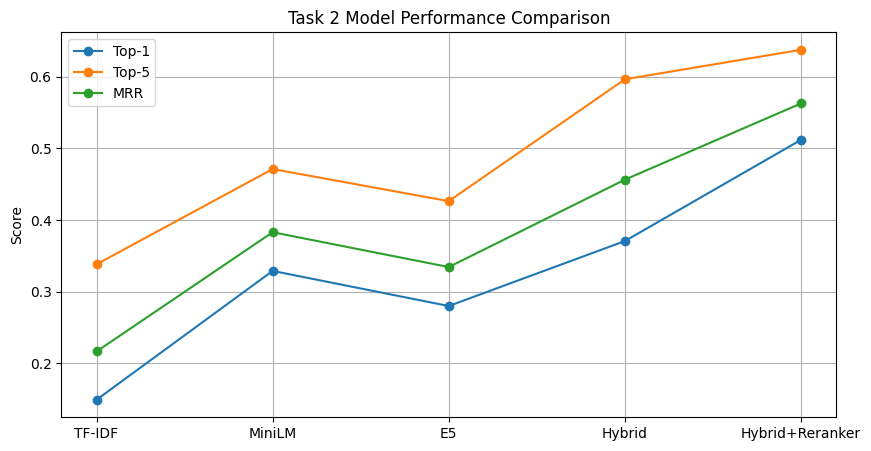

In [74]:
# [Final] Plot model comparison

import matplotlib.pyplot as plt

models = ["TF-IDF", "MiniLM", "E5", "Hybrid", "Hybrid+Reranker"]

top1 = [0.1490, 0.3289, 0.2799, 0.3706, 0.5119]
top5 = [0.3381, 0.4711, 0.4263, 0.5964, 0.6376]
mrr  = [0.2164, 0.3829, 0.3343, 0.4563, 0.5627]

plt.figure(figsize=(10,5))
plt.plot(models, top1, marker='o', label='Top-1')
plt.plot(models, top5, marker='o', label='Top-5')
plt.plot(models, mrr, marker='o', label='MRR')

plt.title("Task 2 Model Performance Comparison")
plt.ylabel("Score")
plt.legend()
plt.grid()

plt.show()

### Performance Trends

The results show a consistent improvement across model complexity:

- TF-IDF provides a strong lexical baseline.
- Dense models (MiniLM, E5) significantly improve semantic understanding.
- Hybrid retrieval combines both signals effectively.
- Reranking yields the largest gain by improving ranking precision.

This confirms that idiom prediction benefits from a multi-stage retrieval architecture.

---
### End of Experiment